# Task : Community Role Classification (Graph-based)

## Goal
Cluster users into behavioral/structural “roles” in the Bluesky block network, using graph + activity features.

Example roles:
- Enforcers: block many (high out activity)
- Victims: blocked often (high in activity)
- Influencers: high followers, low block involvement
- Normal users: low activity / typical behavior


In [1]:
import os
import numpy as np
import pandas as pd

import networkx as nx
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [21]:
GRAPH_PATH = "blocks_graph.graphml"
FEATURES_PATH = "node_features.parquet"

G = nx.read_graphml(GRAPH_PATH)
node_features = pd.read_parquet(FEATURES_PATH)

print("Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")
print("Features shape:", node_features.shape)

node_features.head()


Graph: 32111 nodes, 190849 edges
Features shape: (32111, 13)


,out_degree,in_degree,block_ratio,pagerank,reciprocity,posts_count,following,followers,blocks_given,blocks_received,replies,neighbor_avg_blocks,clustering
did_id,,,,,,,,,,,,,
109144,12,1,6.000000,0.000023,0.00000,169,550,407.0,45,2.0,73.0,90.333333,0.166667
29745745,18,75,0.236842,0.000141,0.00000,396,30,43.0,68,81.0,102.0,56.666667,0.086723
17362021,5,528,0.009452,0.001106,0.00000,50,122,97.0,20,575.0,26.0,53.800000,0.007716
5096582,6,730,0.008208,0.001396,0.00000,340,149,120.0,29,845.0,163.0,208.500000,0.008152
21733425,10,857,0.011655,0.001921,0.00692,475,117,92.0,78,997.0,186.0,68.400000,0.005182


In [23]:
cluster_cols = [
    "blocks_given",
    "blocks_received",
    "followers",
    "following",
    "posts_count",
    "replies",
    "pagerank",
    "clustering",
    "reciprocity",
    "neighbor_avg_blocks",
    "in_degree",
    "out_degree",
]

# keep only existing columns
cluster_cols = [c for c in cluster_cols if c in node_features.columns]
X = node_features[cluster_cols].copy()

# log-transform heavy-tail count features
log_cols = [c for c in ["blocks_given","blocks_received","followers","following","posts_count","replies","in_degree","out_degree"] if c in X.columns]
for c in log_cols:
    X[c] = np.log1p(X[c])

print("Clustering features:", X.shape)
X.head()


Clustering features: (32111, 12)


,blocks_given,blocks_received,followers,following,posts_count,replies,pagerank,clustering,reciprocity,neighbor_avg_blocks,in_degree,out_degree
did_id,,,,,,,,,,,,
109144,3.828641,1.098612,6.011267,6.311735,5.135798,4.304065,0.000023,0.166667,0.00000,90.333333,0.693147,2.564949
29745745,4.234107,4.406719,3.784190,3.433987,5.983936,4.634729,0.000141,0.086723,0.00000,56.666667,4.330733,2.944439
17362021,3.044522,6.356108,4.584967,4.812184,3.931826,3.295837,0.001106,0.007716,0.00000,53.800000,6.270988,1.791759
5096582,3.401197,6.740519,4.795791,5.010635,5.831882,5.099866,0.001396,0.008152,0.00000,208.500000,6.594413,1.945910
21733425,4.369448,6.905753,4.532599,4.770685,6.165418,5.231109,0.001921,0.005182,0.00692,68.400000,6.754604,2.397895


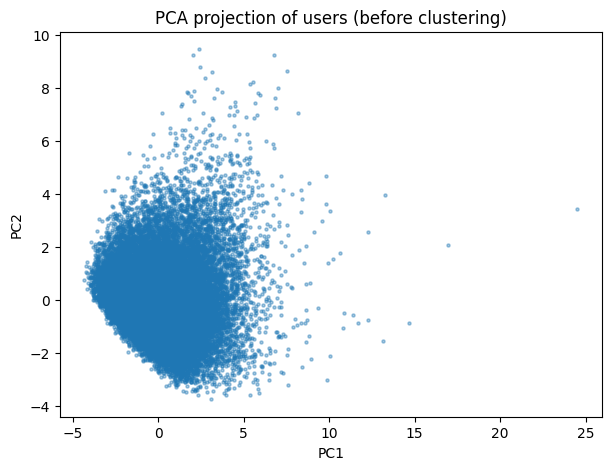

Explained variance ratio: [0.29006049 0.14878774]


In [24]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sc)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], s=5, alpha=0.4)
plt.title("PCA projection of users (before clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


The graph shows a dense blob with a long tail
Very few clearly separated clusters in PC1–PC2


--> Many of the features are highly correlated counts
Heavy-tailed distributions dominate the projection even after log

Let's refine the features

In [25]:
node_features["block_aggression"] = node_features["blocks_given"] / (node_features["blocks_received"] + 1)
node_features["block_activity_ratio"] = node_features["blocks_given"] / (node_features["posts_count"] + 1)
node_features["victim_ratio"] = node_features["blocks_received"] / (node_features["posts_count"] + 1)
node_features["reply_intensity"] = node_features["replies"] / (node_features["posts_count"] + 1)


In [26]:
node_features["relative_blocking"] = (
    node_features["blocks_given"] - node_features["neighbor_avg_blocks"]
)

In [27]:
node_features["influence_score"] = (
    np.log1p(node_features["followers"]) - np.log1p(node_features["blocks_received"] + 1)
)

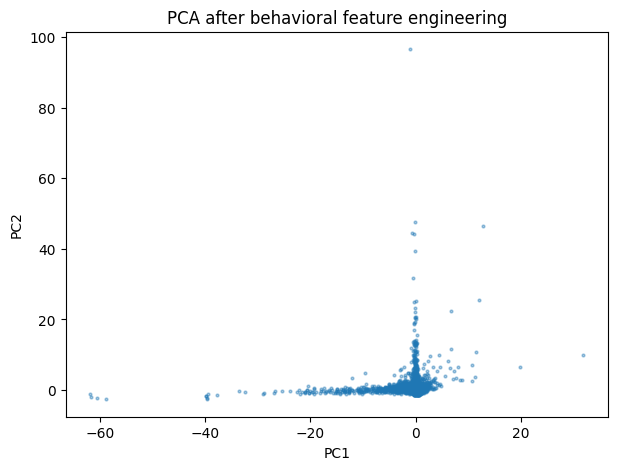

Explained variance: [0.21498346 0.1503837 ]


In [28]:
cluster_cols = [
    "block_aggression",
    "block_activity_ratio",
    "victim_ratio",
    "reply_intensity",
    "neighbor_avg_blocks",
    "relative_blocking",
    "pagerank",
    "clustering",
    "reciprocity",
    "influence_score",
]

X = node_features[cluster_cols].copy()
X = X.replace([np.inf, -np.inf], 0).fillna(0)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_sc)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], s=4, alpha=0.4)
plt.title("PCA after behavioral feature engineering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)


Let's reduce extreme spikes

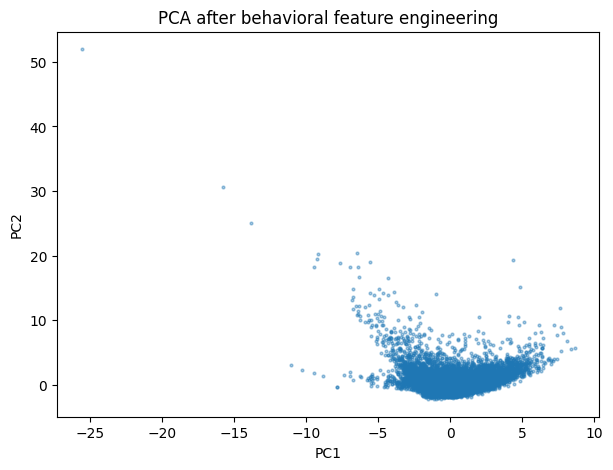

Explained variance: [0.19472262 0.16508722]


In [29]:
ratio_cols = [
    "block_aggression",
    "block_activity_ratio",
    "victim_ratio",
    "reply_intensity",
    "relative_blocking",
]

for c in ratio_cols:
    X[c] = np.log1p(X[c].clip(lower=0))

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_sc)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], s=4, alpha=0.4)
plt.title("PCA after behavioral feature engineering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)


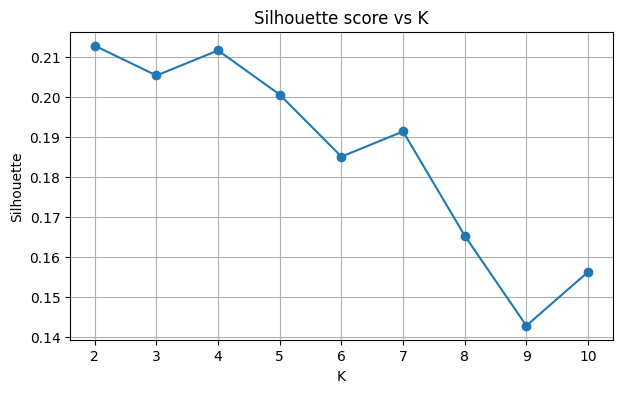

Best K by silhouette: 2


In [15]:
sil_scores = []
Ks = list(range(2, 11))

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_sc)
    sil = silhouette_score(X_sc, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7,4))
plt.plot(Ks, sil_scores, marker="o")
plt.title("Silhouette score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

best_k = Ks[int(np.argmax(sil_scores))]
print("Best K by silhouette:", best_k)


In [75]:
K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_sc)

node_features["role_cluster"] = clusters
print(node_features["role_cluster"].value_counts())


role_cluster
0    25167
1     6944
Name: count, dtype: int64


In [76]:
summary_cols = [c for c in [
    "block_aggression",
    "block_activity_ratio",
    "victim_ratio",
    "reply_intensity",
    "neighbor_avg_blocks",
    "relative_blocking",
    "pagerank",
    "clustering",
    "reciprocity",
    "influence_score",
] if c in node_features.columns]

cluster_summary = node_features.groupby("role_cluster")[summary_cols].median().sort_index()
display(cluster_summary)

cluster_sizes = node_features["role_cluster"].value_counts().sort_index()
display(cluster_sizes)


,block_aggression,block_activity_ratio,victim_ratio,reply_intensity,neighbor_avg_blocks,relative_blocking,pagerank,clustering,reciprocity,influence_score
role_cluster,,,,,,,,,,
0,7.0,0.120401,0.008772,0.598106,39.000000,-16.000000,0.000008,0.0,0.0,2.456736
1,34.0,1.023175,0.003956,0.512962,34.217593,28.472222,0.000008,0.0,0.0,2.484907


role_cluster
0    25167
1     6944
Name: count, dtype: int64

In [77]:
# check a few node ids from each side
g_nodes = list(G.nodes())
nf_nodes = list(node_features.index)

print("G nodes count:", len(g_nodes))
print("node_features rows:", len(nf_nodes))

print("Example G nodes:", g_nodes[:5])
print("Example node_features index:", nf_nodes[:5])

print("Type of G node:", type(g_nodes[0]) if g_nodes else None)
print("Type of node_features index:", type(nf_nodes[0]) if nf_nodes else None)



G nodes count: 32111
node_features rows: 32111
Example G nodes: ['109144', '29745745', '17362021', '5096582', '21733425']
Example node_features index: ['109144', '29745745', '17362021', '5096582', '21733425']
Type of G node: <class 'str'>
Type of node_features index: <class 'str'>


In [78]:
clusters

array([0, 0, 0, ..., 0, 1, 0], shape=(32111,), dtype=int32)

Valid nodes for plotting: 32111
Nodes with cluster labels: 32111
Subgraph nodes: 1000 | edges: 156
Largest component nodes: 50 | edges: 60


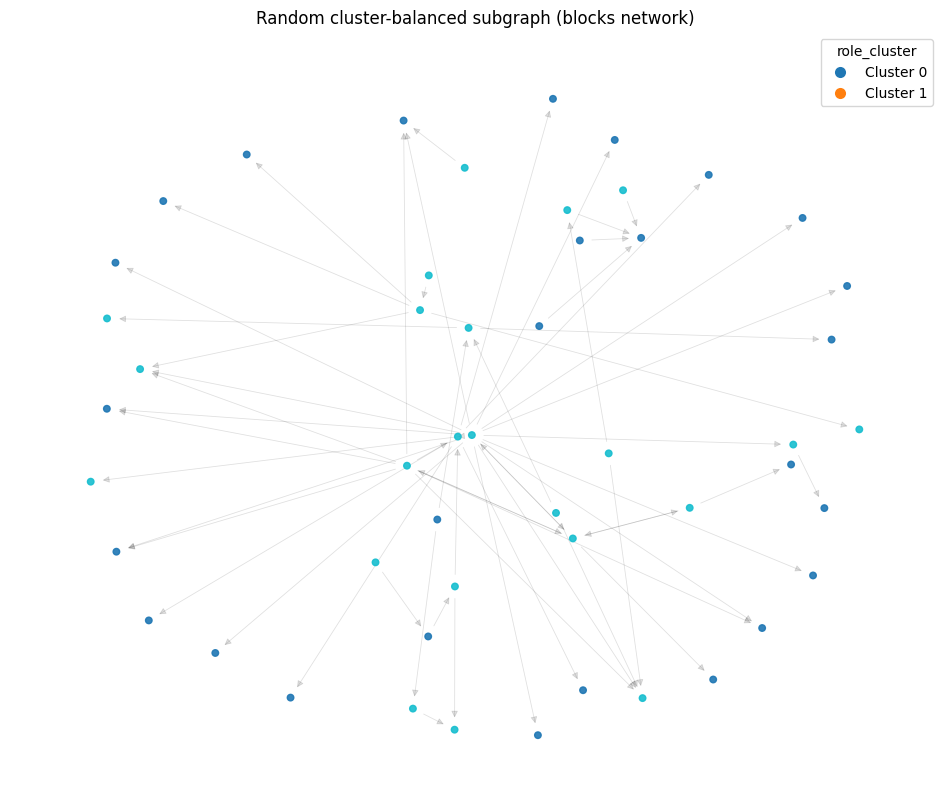

In [83]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ---- 1) Restrict to nodes present in BOTH graph and node_features ----
node_features.index = node_features.index.astype(str)
valid_nodes = list(set(G.nodes()).intersection(node_features.index))
print("Valid nodes for plotting:", len(valid_nodes))

# Attach cluster labels
cluster_map = node_features.loc[valid_nodes, "role_cluster"].to_dict()
nx.set_node_attributes(G, cluster_map, "role_cluster")

# ---- 2) Build dataframe ONLY from valid nodes ----
df_nodes = pd.DataFrame({"node": valid_nodes})
df_nodes["role_cluster"] = df_nodes["node"].map(
    lambda n: G.nodes[n].get("role_cluster", -1)
)

# Remove missing cluster labels
df_nodes = df_nodes[df_nodes["role_cluster"] != -1]

print("Nodes with cluster labels:", len(df_nodes))

# ---- 3) Balanced random sampling across clusters ----
K_PER_CLUSTER = 500
MAX_TOTAL_NODES = 2000

sampled_nodes = []
for c, grp in df_nodes.groupby("role_cluster"):
    take = min(K_PER_CLUSTER, len(grp))
    sampled_nodes.extend(
        grp.sample(n=take, random_state=RANDOM_SEED)["node"].tolist()
    )

if len(sampled_nodes) > MAX_TOTAL_NODES:
    sampled_nodes = rng.choice(sampled_nodes, size=MAX_TOTAL_NODES, replace=False).tolist()

# ---- 4) Subgraph + largest component ----
H = G.subgraph(sampled_nodes).copy()
print("Subgraph nodes:", H.number_of_nodes(), "| edges:", H.number_of_edges())

if G.is_directed():
    comps = list(nx.weakly_connected_components(H))
else:
    comps = list(nx.connected_components(H))

if comps:
    H = H.subgraph(max(comps, key=len)).copy()

print("Largest component nodes:", H.number_of_nodes(), "| edges:", H.number_of_edges())

# ---- 5) Color mapping (FIXED: consistent discrete colors) ----
clusters = sorted(set(nx.get_node_attributes(H, "role_cluster").values()))
cluster_to_idx = {c: i for i, c in enumerate(clusters)}

# Discrete colormap with exactly N colors
cmap = plt.colormaps.get_cmap("tab10")

# Color values must be indices 0..N-1 (not raw cluster labels)
node_color_idx = [cluster_to_idx[H.nodes[n]["role_cluster"]] for n in H.nodes()]

# ---- 6) Plot ----
pos = nx.spring_layout(H, seed=RANDOM_SEED, k=0.3)

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(H, pos, alpha=0.12, width=0.6)
nx.draw_networkx_nodes(
    H, pos,
    node_color=node_color_idx,
    cmap=cmap,
    vmin=0,
    vmax=len(clusters) - 1,
    node_size=22,
    alpha=0.9
)

# Legend: use the SAME cmap and SAME index mapping
legend = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=cmap(cluster_to_idx[c]),
           markeredgecolor='none',
           markersize=8, label=f"Cluster {c}")
    for c in clusters
]
plt.legend(handles=legend, title="role_cluster")

plt.title("Random cluster-balanced subgraph (blocks network)")
plt.axis("off")
plt.show()
